# TPC-C Multi-Tenant with Distributed PVC and Tuned PostgreSQL 17.5

* data is generated and loaded into databases in a distributed filesystem
* experiments do not use preloaded data

* PostgreSQL uses improved args:
```
# --- Connection & Worker Processes ---
- "-c"
- "max_connections=1500"       # https://www.postgresql.org/docs/current/runtime-config-connection.html#GUC-MAX-CONNECTIONS
- "-c"
- "max_worker_processes=128"   # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-WORKER-PROCESSES
- "-c"
- "max_parallel_workers=64"    # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-WORKERS
- "-c"
- "max_parallel_workers_per_gather=8"  # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-WORKERS-PER-GATHER
- "-c"
- "max_parallel_maintenance_workers=8" # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-MAINTENANCE-WORKERS

# --- Memory Settings ---
- "-c"
- "shared_buffers=256GB"       # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-SHARED-BUFFERS
- "-c"
- "effective_cache_size=350GB" # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-EFFECTIVE-CACHE-SIZE
- "-c"
- "work_mem=128MB"             # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-WORK-MEM
- "-c"
- "maintenance_work_mem=4GB"   # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAINTENANCE-WORK-MEM
- "-c"
- "temp_buffers=64MB"          # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-TEMP-BUFFERS
- "-c"
- "wal_buffers=16MB"           # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-BUFFERS
- "-c"
- "autovacuum_work_mem=1GB"    # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-WORK-MEM

# --- Autovacuum ---
- "-c"
- "autovacuum=on"                            # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM
- "-c"
- "autovacuum_max_workers=10"               # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-MAX-WORKERS
- "-c"
- "autovacuum_vacuum_cost_limit=1000"       # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-VACUUM-COST-LIMIT
- "-c"
- "vacuum_cost_limit=1000"                  # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-VACUUM-COST-LIMIT
- "-c"
- "autovacuum_naptime=15s"                  # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-NAPTIME
- "-c"
- "autovacuum_vacuum_cost_delay=20ms"       # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-VACUUM-COST-DELAY

# --- WAL & Checkpoints (Ceph-optimized) ---
- "-c"
- "wal_level=replica"                       # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-LEVEL
- "-c"
- "wal_compression=on"                      # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-COMPRESSION
- "-c"
- "wal_writer_delay=500ms"                  # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-WRITER-DELAY
- "-c"
- "commit_delay=10000"                      # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-COMMIT-DELAY
- "-c"
- "synchronous_commit=off"                  # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-SYNCHRONOUS-COMMIT
- "-c"
- "max_wal_size=2GB"                        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-MAX-WAL-SIZE
- "-c"
- "min_wal_size=1GB"                        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-MIN-WAL-SIZE
- "-c"
- "checkpoint_timeout=15min"                # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-CHECKPOINT-TIMEOUT
- "-c"
- "checkpoint_completion_target=0.9"        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-CHECKPOINT-COMPLETION-TARGET

# --- Planner Cost Tweaks (CephFS) ---
- "-c"
- "random_page_cost=4.0"                    # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-RANDOM-PAGE-COST
- "-c"
- "seq_page_cost=1.5"                       # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-SEQ-PAGE-COST
- "-c"
- "cpu_tuple_cost=0.01"                     # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-CPU-TUPLE-COST
- "-c"
- "effective_io_concurrency=2"              # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-EFFECTIVE-IO-CONCURRENCY
- "-c"
- "default_statistics_target=500"           # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-DEFAULT-STATISTICS-TARGET

# --- Locks and Limits ---
- "-c"
- "max_locks_per_transaction=128"           # https://www.postgresql.org/docs/current/runtime-config-locks.html#GUC-MAX-LOCKS-PER-TRANSACTION
- "-c"
- "max_pred_locks_per_transaction=128"      # https://www.postgresql.org/docs/current/runtime-config-locks.html#GUC-MAX-PRED-LOCKS-PER-TRANSACTION
- "-c"
- "max_stack_depth=7MB"                     # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-STACK-DEPTH
- "-c"
- "max_files_per_process=4000"              # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-FILES-PER-PROCESS

# --- Miscellaneous ---
- "-c"
- "huge_pages=try"                          # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-HUGE-PAGES
```

In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [2]:
def sanitize_filename(title, max_length=100):
    # Replace non-alphanumeric characters with underscores
    safe = re.sub(r'[^a-zA-Z0-9-_]+', '_', title.strip())
    # Truncate to a safe length
    return safe[:max_length].rstrip('_')
    
def plot_bars(df, y, title, estimator):
    df_plot = df.copy()
    #df_plot = df_plot[df_plot['client']=='1']
    df_plot = df_plot.sort_values(['num_tenants','type'])
    # Hatch styles for each type
    hatch_map = {
        'container': '/',
        'database': '\\',
        'schema': 'x',
        'volume': '-'
    }
    hue_order = ['container', 'database', 'schema', 'volume']
    # Create the plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_plot,
        x='num_tenants',
        y=y,
        hue='type',
        estimator=estimator,
        palette='Set2',
        hue_order=hue_order
    )
    show_height = False
    if show_height:
        for bar in ax.patches:
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,  # X: center of bar
                    height,                             # Y: top of bar
                    f'{height:.1f}',                    # Text (1 decimal place)
                    ha='center', va='bottom', fontsize=8
                )
    # Get tick positions (i.e., the x-axis categories)
    xticks = ax.get_xticks()
    bar_width = ax.patches[0].get_width()
    # Create a mapping from (num_tenants, type) to hatch
    grouped = df_plot.groupby(['num_tenants', 'type']).agg({y: estimator}).reset_index()
    #print(grouped)
    grouped_dict = {(row['num_tenants'], row['type']): hatch_map[row['type']] for _, row in grouped.iterrows()}
    bars = sorted(ax.patches, key=lambda bar: bar.get_x() if bar.get_height() > 0 else 10000)
    for bar, (_, row) in zip(bars, grouped.iterrows()):
        bar.my_id = (row['num_tenants'], row['type'])  # or anything else like an index or uuid
        bar.set_hatch(hatch_map[row['type']]) #grouped_dict[(bar.my_id)])
        bar.set_edgecolor('black')
        bar.set_linewidth(1)
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        hatch = hatch_map.get(label, '')
        handle.set_hatch(hatch)
    # Final touches
    plt.legend(title='Type')
    ax.legend(fontsize=18)
    #ax.legend(fontsize=18, loc='upper left', bbox_to_anchor=(1, 1))  # move outside
    plt.title(f"{title}", fontsize=24)
    #plt.title(f"{title} by Number of Tenants and Type", fontsize=24)
    plt.xlabel("Number of Tenants", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    # Remove y-axis label
    ax.set_ylabel('')  # or ax.set(ylabel='')
    plt.tight_layout()
    filename = "tpcc_" + filename_prefix + sanitize_filename(title) + ".png"    
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

def plot_boxplots(df, y, title):
    plt.figure(figsize=(10, 6))
    # Hatch styles for each type
    hatch_map = {
        'container': '/',
        'database': '\\',
        'schema': 'x',
        'volume': '-'
    }
    hue_order = ['container', 'database', 'schema']
    
    # Plot boxplots grouped by num_tenants and colored by type
    ax = sns.boxplot(
        data=df,
        x='num_tenants',
        y=y,#'Goodput (requests/second)',
        hue='type',
        palette='Set2'  # consistent colors per type
    )
    # Add vertical separator lines between groups
    # Get the number of unique num_tenants and type
    num_groups = df['num_tenants'].nunique()
    num_types = df['type'].nunique()
    
    # Extract hue order
    hue_order = ax.get_legend_handles_labels()[1]
    num_hue = len(hue_order)
    
    # Get hue order from seaborn (types)
    _, type_order = ax.get_legend_handles_labels()
    num_types = len(type_order)
    
    #print(len(ax.patches))
    # Set hatches correctly: patches are grouped by x then by hue
    for i, patch in enumerate(ax.patches):
        #print(i)
        type_index = i // (num_groups)
        if type_index >= num_types:
            break
        type_name = type_order[type_index]
        patch.set_hatch(hatch_map.get(type_name, ''))
        #print(hatch_map.get(type_name, ''))
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    
    # Each num_tenants group has num_types boxes
    for i in range(1, num_groups):
        xpos = i - 0.5 #0.5
        ax.axvline(x=xpos, color='gray', linestyle='--', alpha=0.5)
    
    
    # Update legend with matching hatches
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        hatch = hatch_map.get(label, '')
        handle.set_hatch(hatch)
        handle.set_edgecolor('black')
        handle.set_linewidth(1)
    
    #title = "Goodput [req/s] Distribution per Tenant"
    plt.title(title, fontsize=24)
    plt.xlabel("Number of Tenants")
    plt.ylabel("")#"Goodput (requests/second)")
    plt.xlabel("Number of Tenants", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(title="Type")
    ax.legend(fontsize=18)
    plt.tight_layout()
    filename = "tpcc_" + filename_prefix + sanitize_filename(title) + ".png"    
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Collect Results

In [3]:
#path = r"C:\data\benchmarks"
path = r"/home/perdelt/benchmarks"
filename_prefix = "cpupolicy_"

In [4]:
#codes = ['1764670430', '1764628912', '1764645639', '1764606625', '1764648195', '1764661322', '1764632968', '1764625060', '1764613774', '1764666182', '1764654624', '1764617502', '1764637095', '1764610137', '1764611918', '1764603141', '1764650318', '1764601398', '1764604857', '1764668277', '1764652391', '1764623166', '1764643392', '1764634944', '1764626925', '1764657093', '1764630947', '1764621210', '1764672807', '1764663599', '1764639266', '1764608414', '1764641311', '1764619321', '1764615712', '1764659221']
codes = ['1765181901', '1764926888', '1764885402', '1764902218', '1765190850', '1764904498', '1764917698', '1764889541', '1764881374', '1764869893', '1764922484', '1764911000', '1764873679', '1765183672', '1764893584', '1764866240', '1764868052', '1765187192', '1764906674', '1765185393', '1765189017', '1764924647', '1764908771', '1764879453', '1765180111', '1764900011', '1764891526', '1764883360', '1764913385', '1764887528', '1764877463', '1764929312', '1765178354', '1764919961', '1764895754', '1764864459', '1764897823', '1764875535', '1764871864', '1764915506']

codes

['1765181901',
 '1764926888',
 '1764885402',
 '1764902218',
 '1765190850',
 '1764904498',
 '1764917698',
 '1764889541',
 '1764881374',
 '1764869893',
 '1764922484',
 '1764911000',
 '1764873679',
 '1765183672',
 '1764893584',
 '1764866240',
 '1764868052',
 '1765187192',
 '1764906674',
 '1765185393',
 '1765189017',
 '1764924647',
 '1764908771',
 '1764879453',
 '1765180111',
 '1764900011',
 '1764891526',
 '1764883360',
 '1764913385',
 '1764887528',
 '1764877463',
 '1764929312',
 '1765178354',
 '1764919961',
 '1764895754',
 '1764864459',
 '1764897823',
 '1764875535',
 '1764871864',
 '1764915506']

In [5]:
collect = collectors.benchbase(path, codes)

# Monitoring as Time Series

ValueError: boxplot method requires numerical columns, nothing to plot.

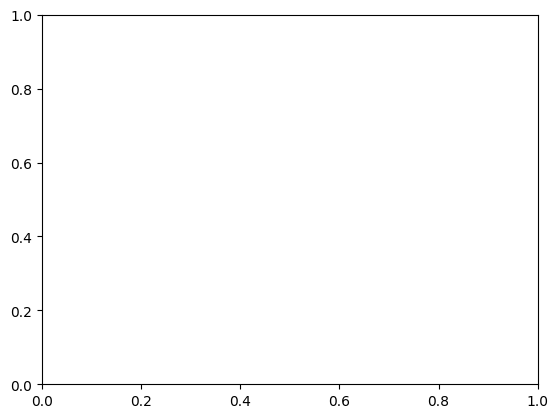

In [6]:
metric = 'pg_stat_database_blks_hit'
#metric = 'pg_stat_database_blks_reads'
#metric = 'pg_stat_activity_count_idle_transaction'
code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)

#df_monitoring.plot(title=metric)
df_monitoring.boxplot()

In [ ]:
metric = 'pg_stat_database_blks_hit'
metric = 'pg_stat_activity_count_idle_transaction'
code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)

df_monitoring.plot(title=metric)

In [ ]:
df_performance = collect.get_monitoring_single_all("stream")
df_performance

# Monitoring Aggregated Values

In [ ]:
df_performance = collect.get_monitoring_all("stream")

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance#[['Max CPU', 'client', 'type', 'num_tenants']]

In [ ]:
plot_bars(df_performance.fillna(0), y='Cache Hit Ratio [%]', title='Cache Hit Ratio [%]', estimator='min')

In [ ]:
plot_bars(df_performance, y='Block Hits', title='Block Hits', estimator='min')

In [ ]:
plot_bars(df_performance, y='Block Reads', title='Block Reads', estimator='max')

In [ ]:
plot_bars(df_performance, y='Number Autoanalyze', title='Number Autoanalyze', estimator='max')

In [ ]:
plot_bars(df_performance, y='Number Autovacuum', title='Number Autovacuum', estimator='max')

In [ ]:
plot_bars(df_performance, y='Heap Reads', title='Heap Reads', estimator='max')

In [ ]:
plot_bars(df_performance, y='Heap Hits', title='Heap Hits', estimator='min')

In [ ]:
plot_bars(df_performance, y='Idle', title='Idle', estimator='max')

In [ ]:
plot_bars(df_performance, y='Transactions Idle', title='Transactions Idle', estimator='max')

In [ ]:
plot_bars(df_performance, y='Transactions Aborted', title='Transactions Aborted', estimator='max')

In [ ]:
plot_bars(df_performance, y='Active', title='Active', estimator='max')

In [ ]:
plot_bars(df_performance, y='Locks', title='Locks', estimator='max')

In [ ]:
plot_bars(df_performance, y='Sync Time', title='Sync Time [ms]', estimator='max')

In [ ]:
plot_bars(df_performance, y='Write Time', title='Write Time [ms]', estimator='max')

In [ ]:
#plot_bars(df_performance, y='Variance of Core Util [%]', title='Variance of Core Util [%]', estimator='max')

# Performance Results per Tenant

In [7]:
df_performance = collect.get_performance_all_single()

df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

,connection,configuration,experiment_run,client,pod,pod_count,bench,profile,target,time,...,Latency Distribution.Minimum Latency (microseconds),Latency Distribution.25th Percentile Latency (microseconds),Latency Distribution.90th Percentile Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),Latency Distribution.75th Percentile Latency (microseconds),Latency Distribution.Average Latency (microseconds),type,num_tenants,vol_tenants,code
connection_pod,,,,,,,,,,,,,,,,,,,,,
PostgreSQL-1-1-65536-0-1-1,PostgreSQL-1-1-65536-0-1,PostgreSQL-1-1-65536-0,1,1,4l88j.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,642,18350,117633,265671,90351,60086,container,1,False,1765183672
PostgreSQL-1-1-65536-0-2-1,PostgreSQL-1-1-65536-0-2,PostgreSQL-1-1-65536-0,1,2,zzjcr.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,742,11798,47042,100088,28914,23562,container,1,False,1765183672
PostgreSQL-1-1-65536-1-1,PostgreSQL-1-1-65536-1,PostgreSQL-1-1-65536,1,1,rwpch.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,627,17844,106194,213392,85542,55948,database,1,False,1765180111
PostgreSQL-1-1-65536-2-1,PostgreSQL-1-1-65536-2,PostgreSQL-1-1-65536,1,2,pr5bk.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,719,12196,48576,105815,29814,24559,database,1,False,1765180111
PostgreSQL-1-1-65536-1-1,PostgreSQL-1-1-65536-1,PostgreSQL-1-1-65536,1,1,87v92.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,658,17911,113986,345565,83685,60792,schema,1,False,1765178354
PostgreSQL-1-1-65536-2-1,PostgreSQL-1-1-65536-2,PostgreSQL-1-1-65536,1,2,58gr6.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,748,11826,48895,104819,29964,29556,schema,1,False,1765178354
PostgreSQL-1-1-65536-1-1,PostgreSQL-1-1-65536-1,PostgreSQL-1-1-65536,1,1,w4xlz.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,586,16853,113547,359775,84572,60468,volume,1,True,1765181901
PostgreSQL-1-1-65536-2-1,PostgreSQL-1-1-65536-2,PostgreSQL-1-1-65536,1,2,bxxmz.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,724,11878,48945,107210,29380,24252,volume,1,True,1765181901
PostgreSQL-1-1-65536-0-1-1,PostgreSQL-1-1-65536-0-1,PostgreSQL-1-1-65536-0,1,1,69hrw.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,721,19979,101118,202619,75748,52241,container,2,False,1765190850


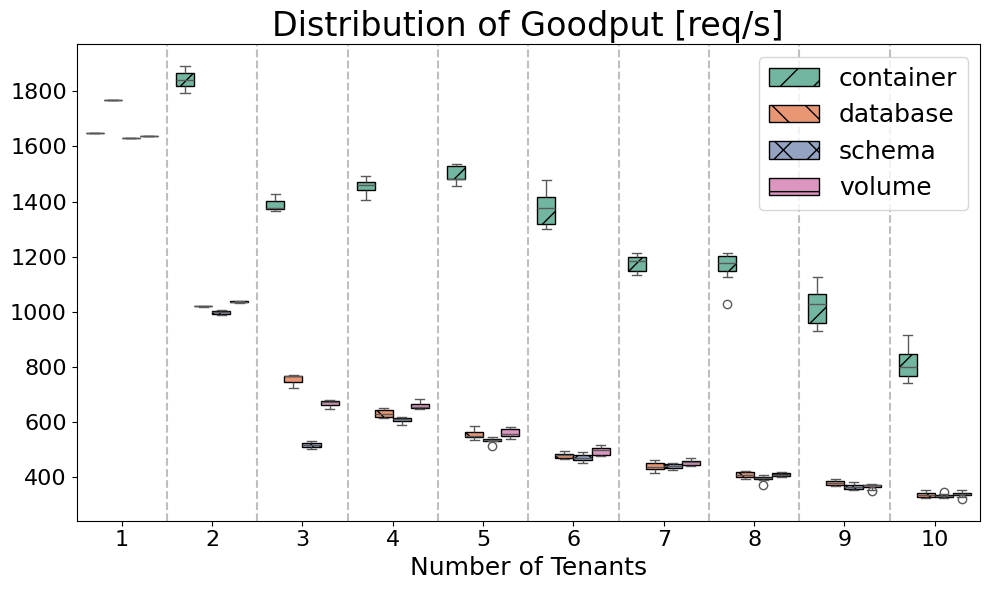

In [8]:
plot_boxplots(df_performance_first, y='Goodput (requests/second)', title='Distribution of Goodput [req/s]')

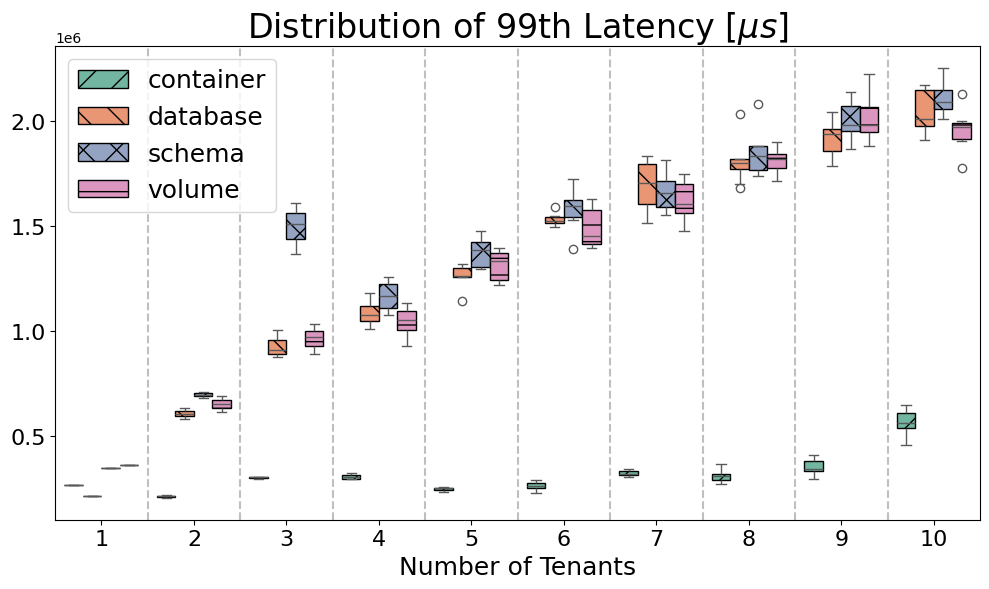

In [9]:
plot_boxplots(df_performance_first, y='Latency Distribution.99th Percentile Latency (microseconds)', title='Distribution of 99th Latency [$\mu s$]')

# Performance Results per Total

In [10]:
df_performance = collect.get_performance_all()
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.dropna(inplace=True)
df_performance

,client,Goodput (requests/second),num_errors,Latency Distribution.Average Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),type,num_tenants,vol_tenants,code
0,1,1648.518140,9,60086.000000,265671,container,1,False,1765183672
1,2,4182.789715,48,23562.000000,100088,container,1,False,1765183672
0,1,1770.251589,9,55948.000000,213392,database,1,False,1765180111
1,2,4013.778193,54,24559.000000,105815,database,1,False,1765180111
0,1,1628.988325,7,60792.000000,345565,schema,1,False,1765178354
1,2,3336.106370,40,29556.000000,104819,schema,1,False,1765178354
0,1,1637.784816,11,60468.000000,359775,volume,1,True,1765181901
1,2,4065.613195,64,24252.000000,107210,volume,1,True,1765181901
0,1,3686.161328,35,53684.500000,218840,container,2,False,1765190850
1,2,6911.148087,144,28501.500000,116327,container,2,False,1765190850


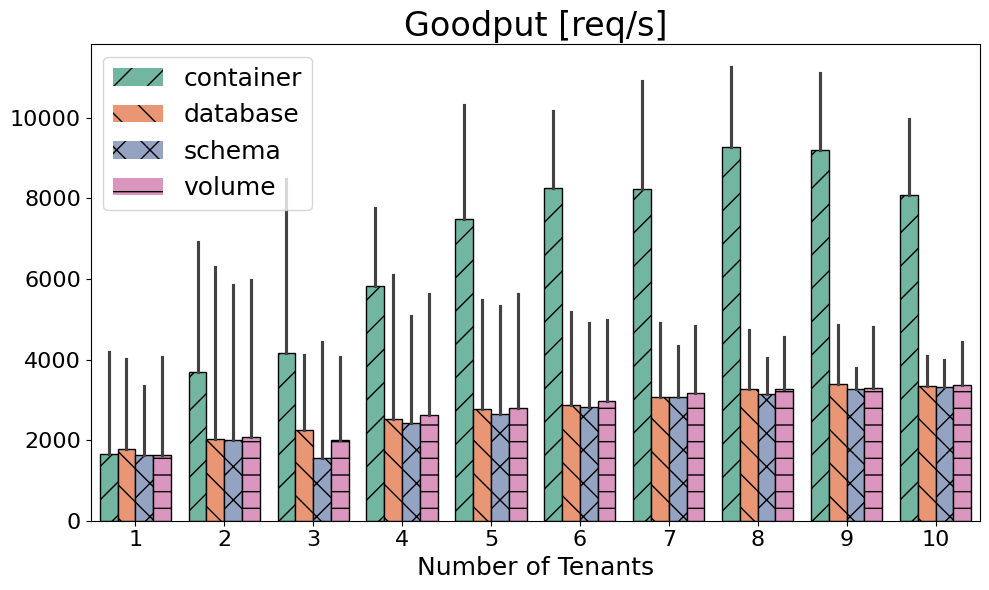

In [11]:
plot_bars(df_performance, y='Goodput (requests/second)', title='Goodput [req/s]', estimator='min')

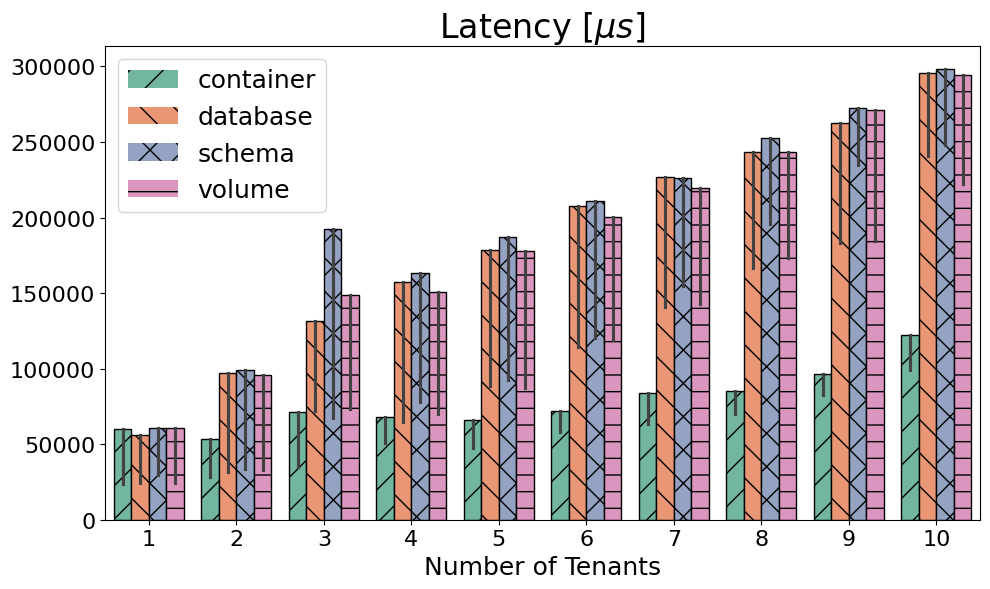

In [12]:
plot_bars(df_performance, y='Latency Distribution.Average Latency (microseconds)', title='Latency [$\mu s$]', estimator='max')

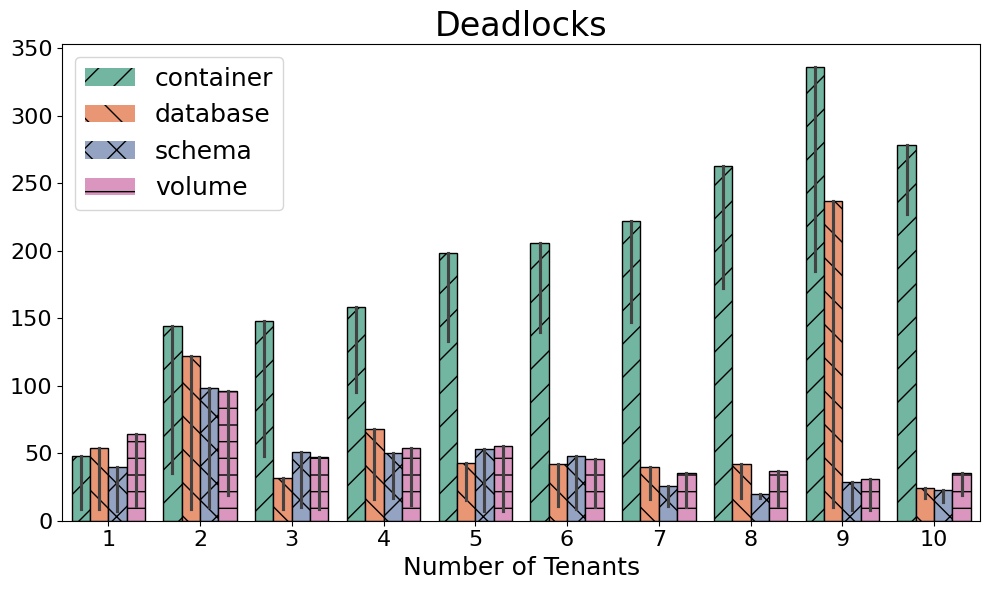

In [13]:
plot_bars(df_performance, y='num_errors', title='Deadlocks', estimator='max')

In [14]:
df_performance = collect.get_loading_time_max_all()
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

,time_load,time_ingest,time_check,terminals,pods,tenant,client,datadisk,type,num_tenants,vol_tenants,code
PostgreSQL-1-1-65536-0-1,223.0,88.0,134.0,1,1,0,1,2720,container,1,False,1765183672
PostgreSQL-1-1-65536-0-2,223.0,88.0,134.0,1,1,0,2,5458,container,1,False,1765183672
PostgreSQL-1-1-65536-1,325.0,122.0,202.0,1,1,,1,2727,database,1,False,1765180111
PostgreSQL-1-1-65536-2,325.0,122.0,202.0,1,1,,2,5708,database,1,False,1765180111
PostgreSQL-1-1-65536-1,275.0,105.0,169.0,1,1,,1,2720,schema,1,False,1765178354
PostgreSQL-1-1-65536-2,275.0,105.0,169.0,1,1,,2,5502,schema,1,False,1765178354
PostgreSQL-1-1-65536-1,274.0,106.0,168.0,1,1,,1,2727,volume,1,True,1765181901
PostgreSQL-1-1-65536-2,274.0,106.0,168.0,1,1,,2,5526,volume,1,True,1765181901
PostgreSQL-1-1-65536-0-1,330.0,119.0,211.0,1,1,0,1,2720,container,2,False,1765190850
PostgreSQL-1-1-65536-0-2,330.0,119.0,211.0,1,1,0,2,5934,container,2,False,1765190850


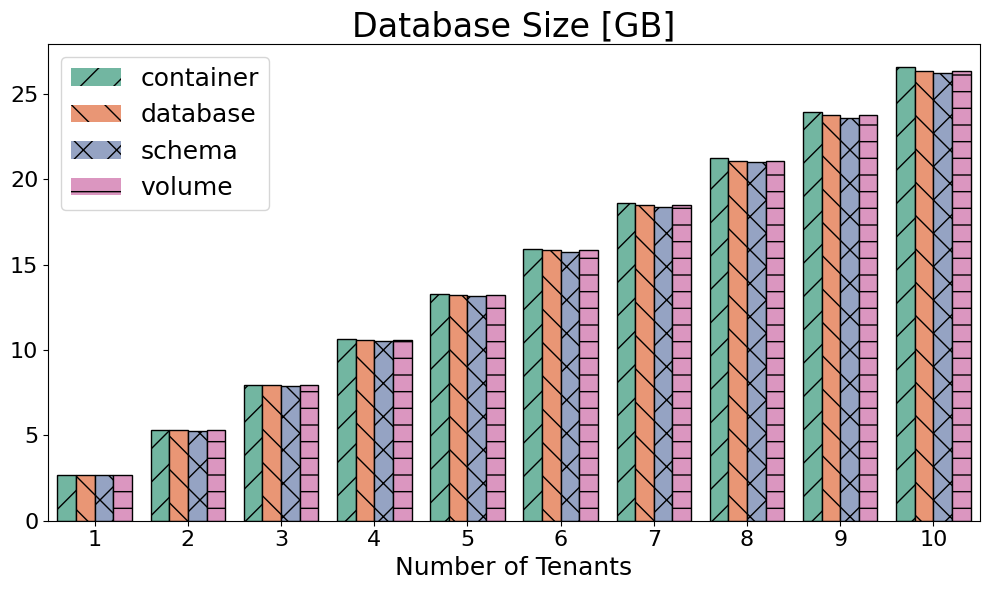

In [15]:
df_performance_first = df_performance[df_performance['client'] == '1']
# Divide datadisk by the count of rows with the same type and num_tenants
df = df_performance_first.copy()
# Create a mask for rows where type is not "container"
mask = df['type'] != 'container'

# Only apply the group count to the relevant rows
group_counts = df[mask].groupby(['type', 'num_tenants'])['datadisk'].transform('count')

# Initialize the column with NaN (or 0, if preferred)
df['datadisk_normalized'] = df['datadisk'] / 1024

# Apply the normalized value only where the mask is True
df.loc[mask, 'datadisk_normalized'] = df.loc[mask, 'datadisk'] / group_counts / 1024

plot_bars(df, y='datadisk_normalized', title='Database Size [GB]', estimator='sum')

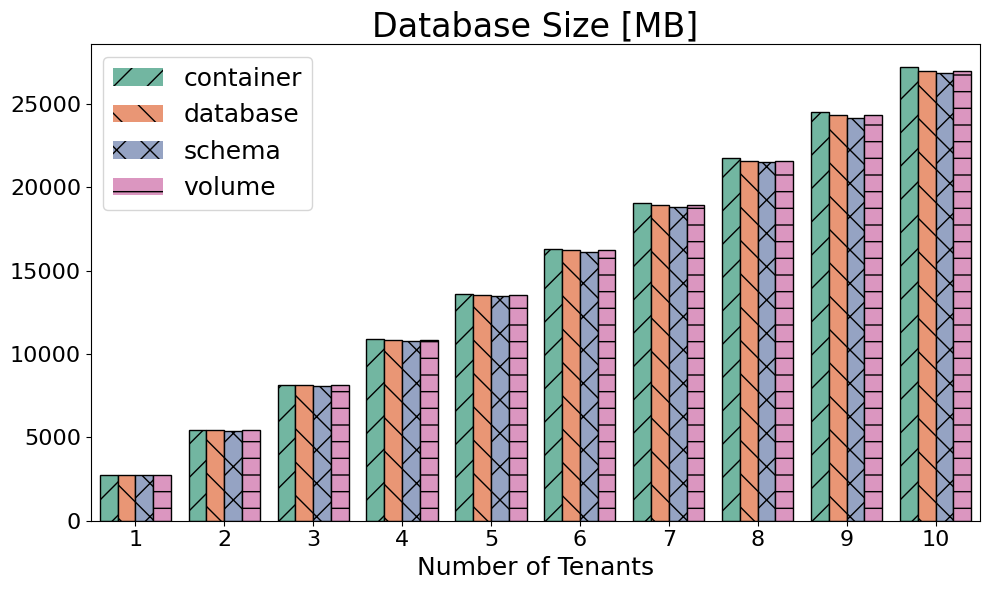

In [16]:
plot_bars(df_performance_first, y='datadisk', title='Database Size [MB]', estimator='sum')

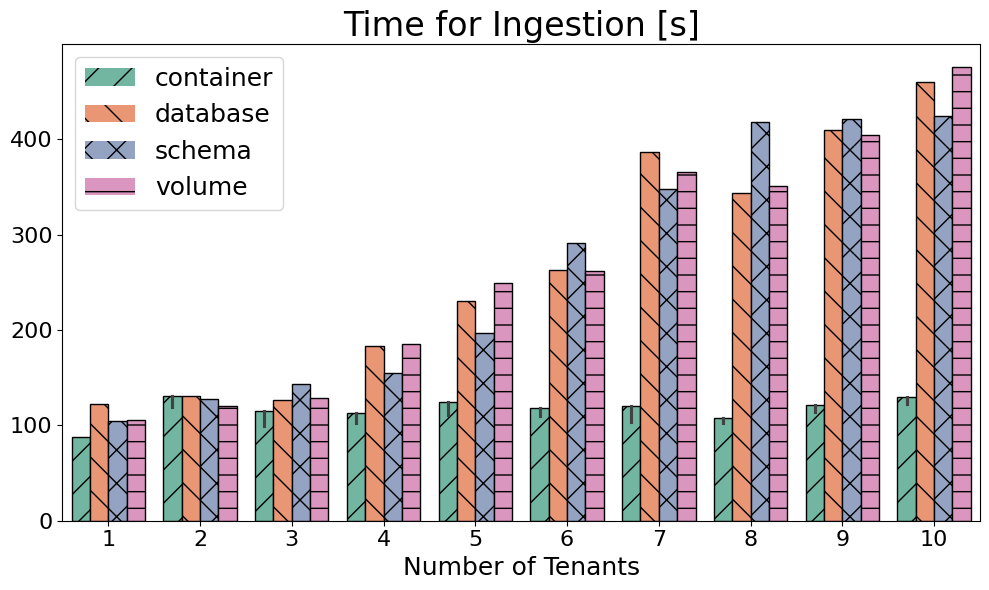

In [17]:
plot_bars(df_performance_first, y='time_ingest', title='Time for Ingestion [s]', estimator='max')

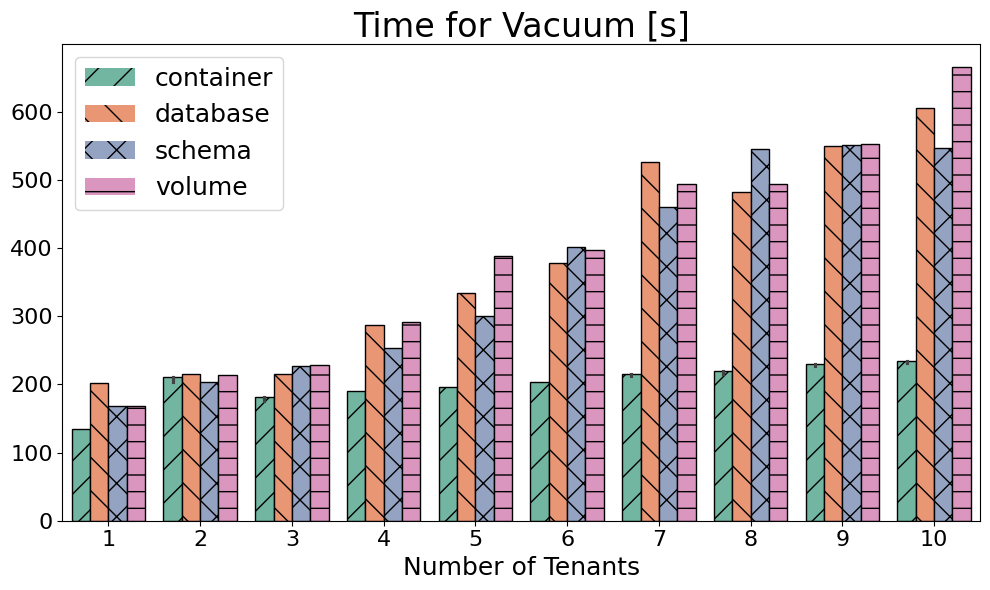

In [18]:
plot_bars(df_performance_first, y='time_check', title='Time for Vacuum [s]', estimator='max')

# Hardware Monitoring for Benchmarking Phase

In [19]:
df_performance = collect.get_monitoring_all(type="stream")
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.T

,0,1,0,1,0,1,0,1,0,1,...,0,1,0,1,0,1,0,1,0,1
client,1,2,1,2,1,2,1,2,1,2,...,1,2,1,2,1,2,1,2,1,2
Memory Usage [MiB],5010.78,6549.65,5014.88,6650.52,5007.31,6180.76,4977.77,6628.8,10019.53,12933.94,...,26711.74,29832.49,44938.61,49971.63,28837.61,32263.91,28444.61,31987.43,28968.4,31723.0
Memory Usage Cached [MiB],6647.0,9538.08,6680.85,9687.62,6652.29,8887.87,6628.26,9668.63,13333.71,18732.49,...,37487.13,42984.03,57852.86,67422.71,40624.36,46341.43,40160.55,46006.36,40742.54,45809.03
CPU Utilization,12.87,20.74,13.71,20.15,13.2,16.67,13.13,20.93,30.59,32.52,...,28.65,33.87,47.35,46.65,29.02,28.96,30.73,38.34,29.03,29.78
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],8123.69,13887.07,8677.84,12231.78,8231.54,11225.36,7843.11,13627.52,20035.59,20472.9,...,17423.45,22643.73,30153.43,30715.91,18448.1,17923.45,20164.88,24737.33,17874.85,20137.27
CPU User Time [s],6001.44,9233.34,6393.24,8297.82,6101.56,7529.04,5818.36,9170.12,15185.66,14587.33,...,12860.52,16519.99,21575.49,21034.96,13489.53,12855.3,15138.26,19156.48,12983.4,14256.46
CPU System Time [s],2122.25,4653.73,2284.6,3933.97,2129.99,3696.32,2024.75,4457.4,4849.93,5885.56,...,4562.93,6123.74,8577.94,9680.97,4958.57,5068.15,5026.62,5580.85,4891.45,5880.81
Network Rx Total [MiB],6993.63,13529.07,7295.26,12845.55,6891.92,11811.4,6762.68,12845.03,15555.37,21436.88,...,13647.25,12567.3,34000.88,41030.49,13758.36,11069.03,13987.58,10475.1,14320.46,11587.55


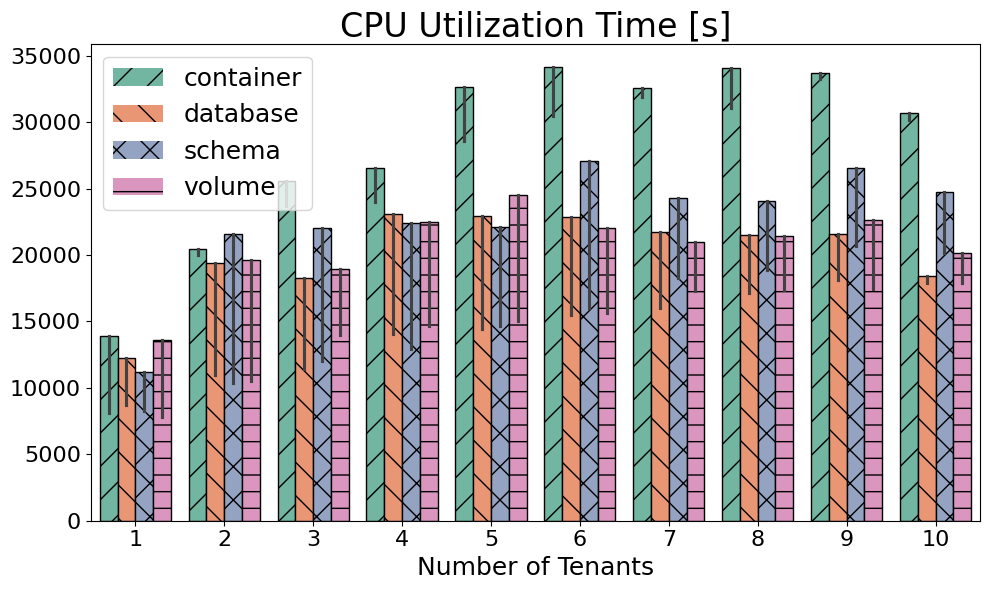

In [20]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU Utilization Time [s]', estimator='max')

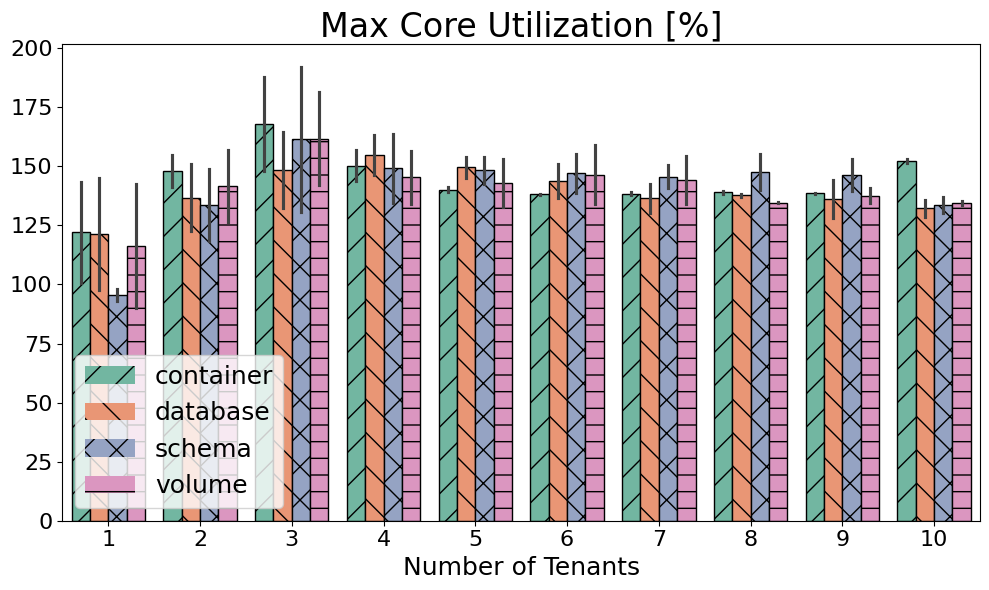

In [21]:
plot_bars(df_performance, y='Max Core Utilization [%]', title='Max Core Utilization [%]', estimator='sum')

In [23]:
#plot_bars(df_performance, y='CPU Throttled', title='CPU Throttled', estimator='sum')

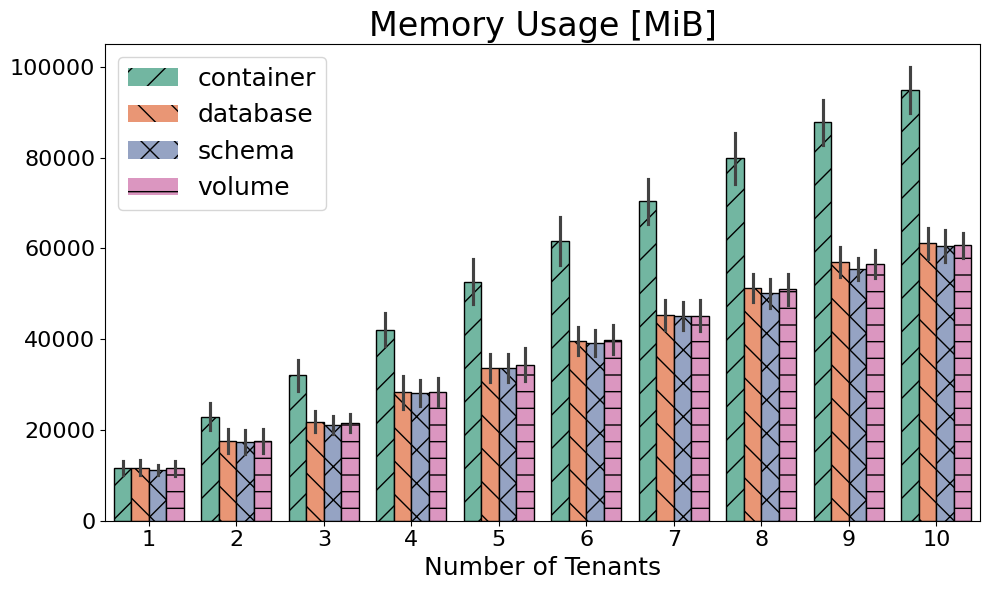

In [24]:
plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='sum')

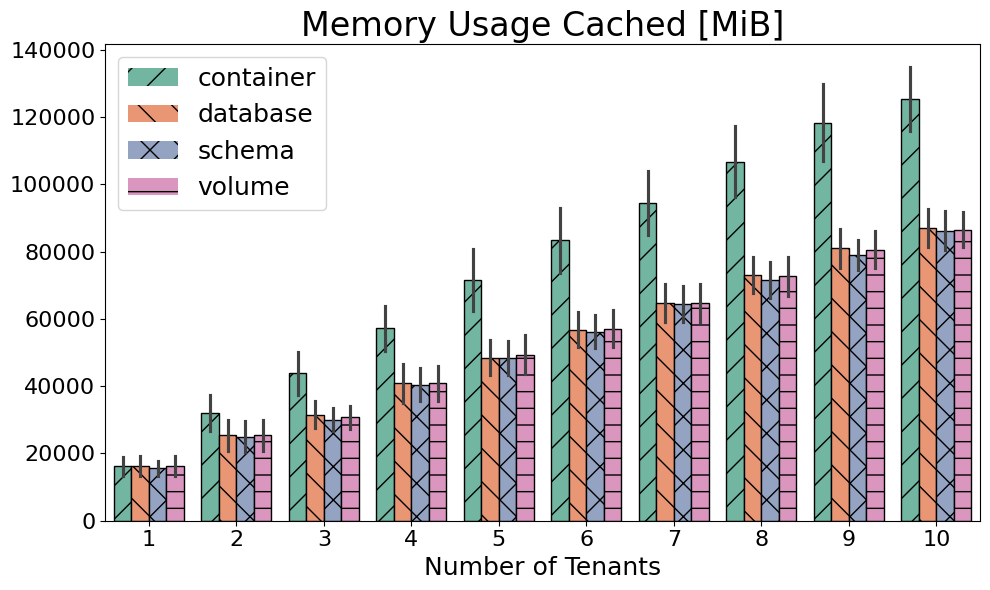

In [25]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='sum')

# Hardware Monitoring for Loading Phase

In [26]:
df_performance = collect.get_monitoring_all("loading")
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

,client,Memory Usage [MiB],Memory Usage Cached [MiB],CPU Utilization,CPU Throttle,CPU Throttled Time [s],CPU Utilization Time [s],CPU User Time [s],CPU System Time [s],Network Rx Total [MiB],...,Filesystem Read Total [MiB],Filesystem Write Total [MiB],Core Utilization Variance [%],Max Core Utilization [%],I/O Wait [%],Total I/O Wait Time [s],type,num_tenants,vol_tenants,code
0,1,2996.50,3452.00,1.83,0.0,0.0,429.34,385.35,43.98,1124.00,...,0.00,0.01,0.08,1.17,56.27,124.98,container,1,False,1765183672
1,2,2996.50,3452.00,1.83,0.0,0.0,429.34,385.35,43.98,1124.00,...,0.00,0.01,0.08,1.17,56.27,124.98,container,1,False,1765183672
0,1,3109.09,3704.73,1.96,0.0,0.0,422.45,383.44,39.01,1132.17,...,0.00,0.01,0.17,3.08,55.19,270.32,database,1,False,1765180111
1,2,3109.09,3704.73,1.96,0.0,0.0,422.45,383.44,39.01,1132.17,...,0.00,0.01,0.17,3.08,55.19,270.32,database,1,False,1765180111
0,1,3052.56,3608.50,2.74,0.0,0.0,486.49,444.67,41.82,1105.71,...,0.00,0.01,0.18,2.27,56.26,243.36,schema,1,False,1765178354
1,2,3052.56,3608.50,2.74,0.0,0.0,486.49,444.67,41.82,1105.71,...,0.00,0.01,0.18,2.27,56.26,243.36,schema,1,False,1765178354
0,1,3125.18,3717.33,2.80,0.0,0.0,463.86,420.73,43.12,1125.18,...,0.01,0.02,0.15,1.93,53.66,235.73,volume,1,True,1765181901
1,2,3125.18,3717.33,2.80,0.0,0.0,463.86,420.73,43.12,1125.18,...,0.01,0.02,0.15,1.93,53.66,235.73,volume,1,True,1765181901
0,1,6171.25,7330.27,4.37,0.0,0.0,901.24,811.27,89.97,2259.48,...,0.00,0.02,0.32,4.87,47.80,265.71,container,2,False,1765190850
1,2,6171.25,7330.27,4.37,0.0,0.0,901.24,811.27,89.97,2259.48,...,0.00,0.02,0.32,4.87,47.80,265.71,container,2,False,1765190850


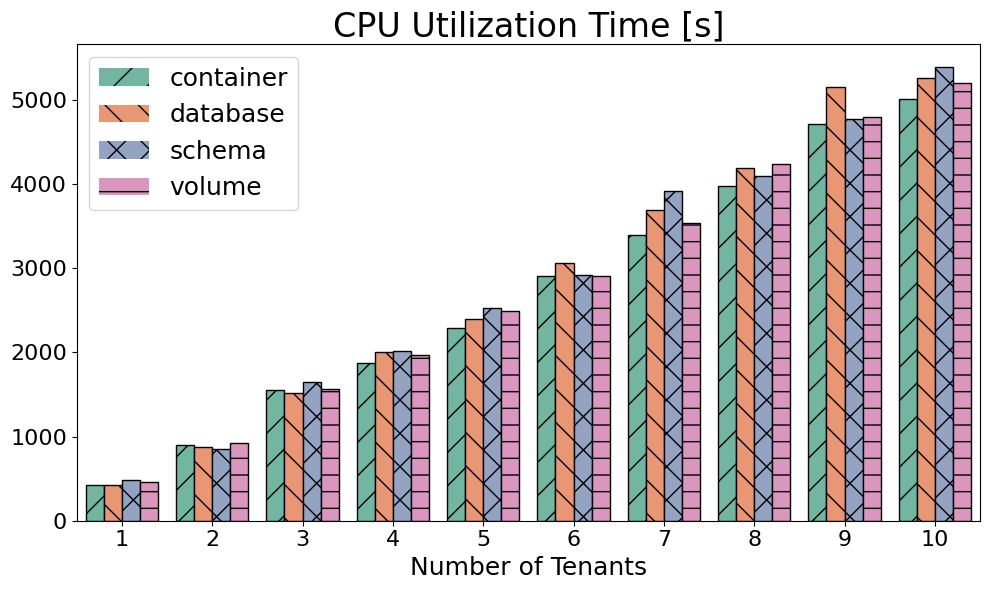

In [28]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU Utilization Time [s]', estimator='max')

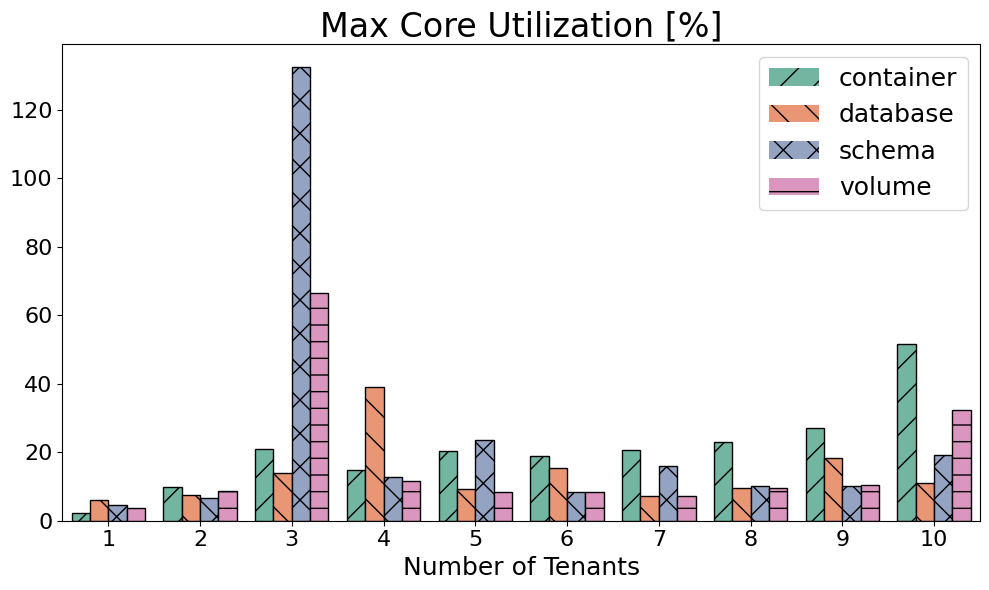

In [29]:
plot_bars(df_performance, y='Max Core Utilization [%]', title='Max Core Utilization [%]', estimator='sum')

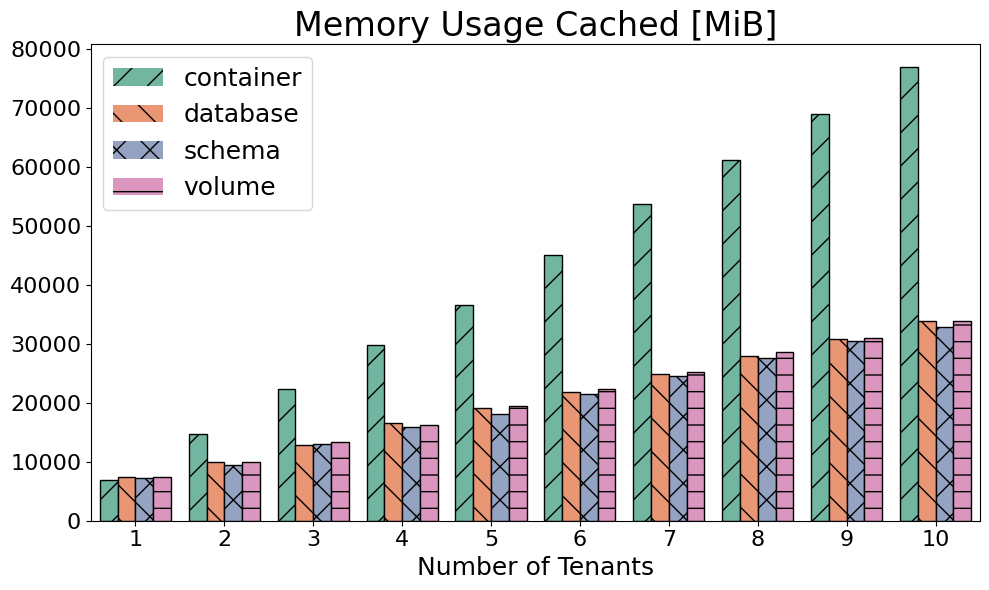

In [30]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='sum')

# Efficiency

In [31]:
client = '1'

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance_monitoring.loc[df_performance_monitoring['vol_tenants'] == True, 'type'] = 'volume'
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

,client,Goodput (requests/second),num_errors,Latency Distribution.Average Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),type,num_tenants,vol_tenants_x,code,Memory Usage [MiB],...,Filesystem Read Total [MiB],Filesystem Write Total [MiB],Core Utilization Variance [%],Max Core Utilization [%],I/O Wait [%],Total I/O Wait Time [s],vol_tenants_y,E_Tpx,E_Lat,E_RAM
0,1,1648.518140,9,60086.000000,265671,container,1,False,1765183672,5010.78,...,0.01,0.00,3.08,50.41,7.77,478.88,False,121.756355,0.045262,0.328994
1,1,1770.251589,9,55948.000000,213392,database,1,False,1765180111,5014.88,...,0.01,0.00,3.04,48.76,8.53,467.24,False,122.398080,0.045384,0.353000
2,1,1628.988325,7,60792.000000,345565,schema,1,False,1765178354,5007.31,...,0.00,0.00,3.02,46.54,7.25,396.59,False,118.737562,0.044703,0.325322
3,1,1637.784816,11,60468.000000,359775,volume,1,True,1765181901,4977.77,...,0.00,0.00,2.78,44.99,7.83,386.14,True,125.290974,0.045919,0.329020
4,1,3686.161328,35,53684.500000,218840,container,2,False,1765190850,10019.53,...,0.01,0.00,1.88,70.56,5.69,497.37,False,110.388404,0.030491,0.367898
5,1,2038.608283,9,97253.000000,631899,database,2,False,1765187192,7473.74,...,0.01,0.00,3.54,61.31,6.39,367.73,False,111.166396,0.030570,0.272769
6,1,1994.974870,10,99363.500000,710062,schema,2,False,1765185393,7395.98,...,0.00,0.00,3.37,59.24,6.28,435.83,False,115.486135,0.031161,0.269738
7,1,2071.370080,19,95696.500000,689466,volume,2,True,1765189017,7499.56,...,0.00,0.00,3.50,63.26,7.24,419.63,True,117.990480,0.031497,0.276199
8,1,4168.436463,48,71087.000000,306046,container,3,False,1764869893,14329.17,...,0.00,0.00,0.29,73.91,1.68,136.17,False,105.727127,0.024386,0.290906
9,1,2257.773177,9,131836.333333,1005329,database,3,False,1764866240,9734.95,...,0.00,0.00,3.32,66.27,3.53,326.12,False,118.729560,0.025784,0.231924


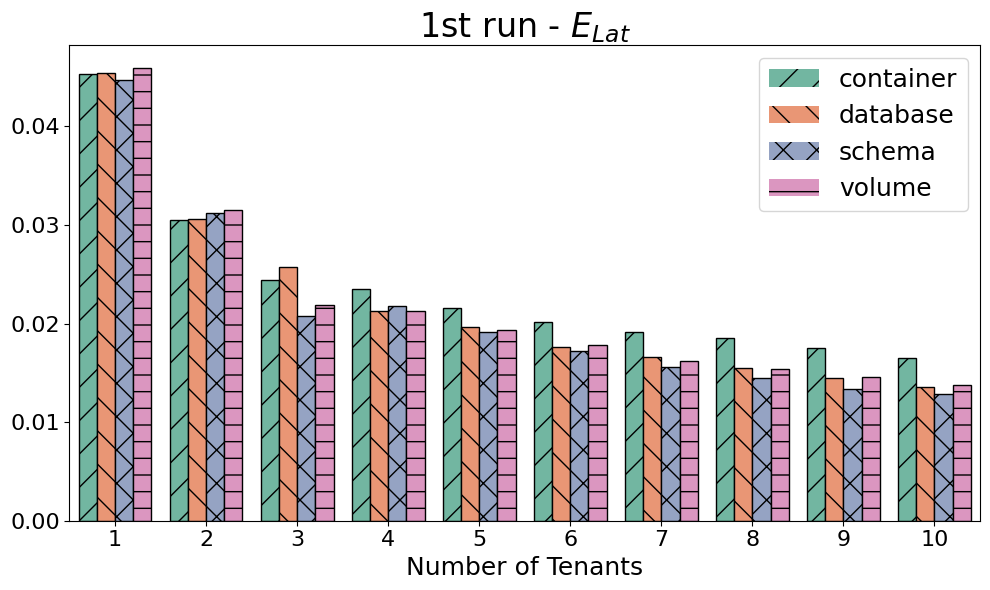

In [32]:
plot_bars(merged_df, y='E_Lat', title='1st run - $E_{Lat}$', estimator='max')

In [33]:
#plot_bars(merged_df, y='I_Lat', title='1st run - $I_{Lat}$', estimator='max')

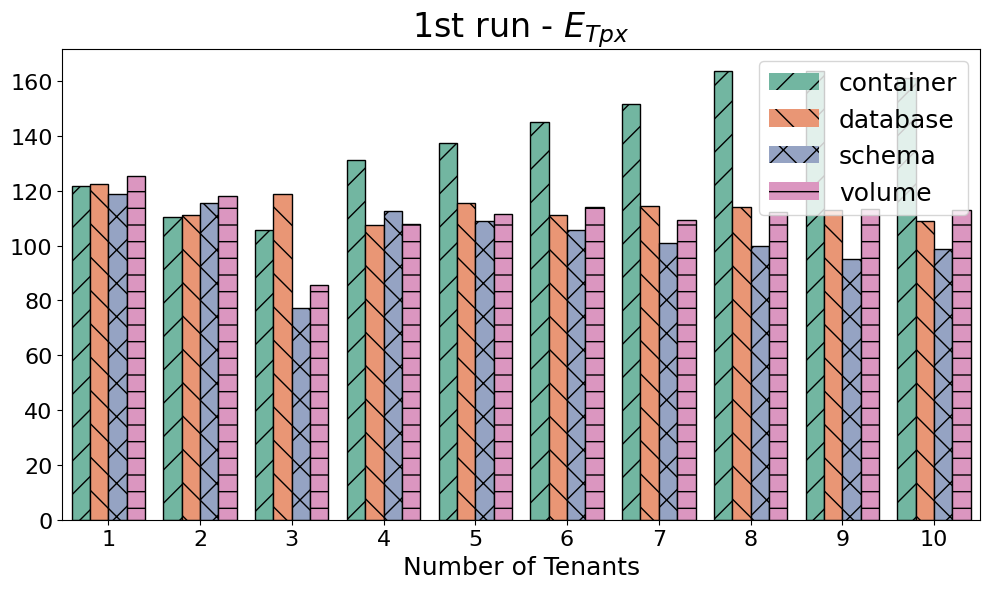

In [34]:
plot_bars(merged_df, y='E_Tpx', title='1st run - $E_{Tpx}$', estimator='max')

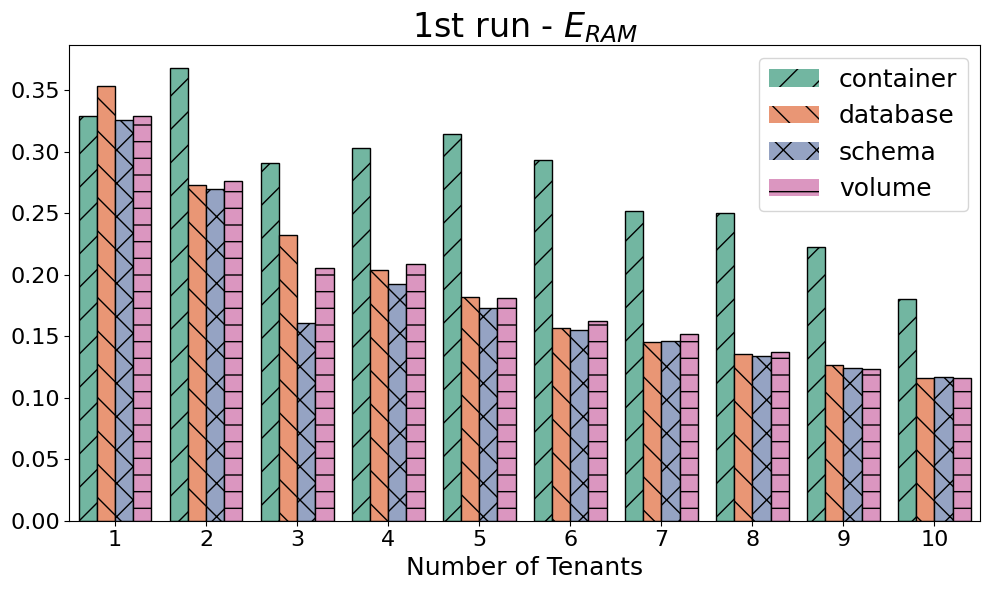

In [35]:
plot_bars(merged_df, y='E_RAM', title='1st run - $E_{RAM}$', estimator='min')

In [40]:
client = '2'

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance_monitoring.loc[df_performance_monitoring['vol_tenants'] == True, 'type'] = 'volume'
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

,client,Goodput (requests/second),num_errors,Latency Distribution.Average Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),type,num_tenants,vol_tenants_x,code,Memory Usage [MiB],...,Filesystem Read Total [MiB],Filesystem Write Total [MiB],Core Utilization Variance [%],Max Core Utilization [%],I/O Wait [%],Total I/O Wait Time [s],vol_tenants_y,E_Tpx,E_Lat,E_RAM
0,2,4182.789715,48,23562.000000,100088,container,1,False,1765183672,6549.65,...,0.00,0.0,3.91,71.74,4.29,464.48,False,180.720183,0.055283,0.638628
1,2,4013.778193,54,24559.000000,105815,database,1,False,1765180111,6650.52,...,0.00,0.0,4.04,72.50,4.97,493.92,False,196.886055,0.057697,0.603528
2,2,3336.106370,40,29556.000000,104819,schema,1,False,1765178354,6180.76,...,0.00,0.0,2.65,49.13,5.50,468.65,False,178.316225,0.054901,0.539757
3,2,4065.613195,64,24252.000000,107210,volume,1,True,1765181901,6628.80,...,0.00,0.0,3.82,71.29,4.13,449.95,True,179.003070,0.055007,0.613326
4,2,6911.148087,144,28501.500000,116327,container,2,False,1765190850,12933.94,...,0.00,0.0,1.60,77.30,2.76,565.47,False,202.545260,0.041398,0.534342
5,2,6291.361654,122,31304.500000,125396,database,2,False,1765187192,10125.95,...,0.00,0.0,2.27,75.39,2.93,382.97,False,194.258270,0.040545,0.621311
6,2,5852.538042,98,33696.000000,148872,schema,2,False,1765185393,9983.54,...,0.00,0.0,2.11,74.45,2.24,309.85,False,162.710688,0.037083,0.586219
7,2,5968.026246,96,33043.000000,145390,volume,2,True,1765189017,10096.01,...,0.00,0.0,2.32,78.56,2.21,358.71,True,182.443635,0.039268,0.591127
8,2,8471.157758,148,34846.000000,142385,container,3,False,1764869893,17741.28,...,0.00,0.0,1.30,94.00,1.10,277.27,False,198.735207,0.033498,0.477483
9,2,4118.064767,32,71926.000000,347648,database,3,False,1764866240,12105.00,...,0.00,0.0,1.01,82.19,1.57,207.74,False,135.202703,0.027582,0.340195


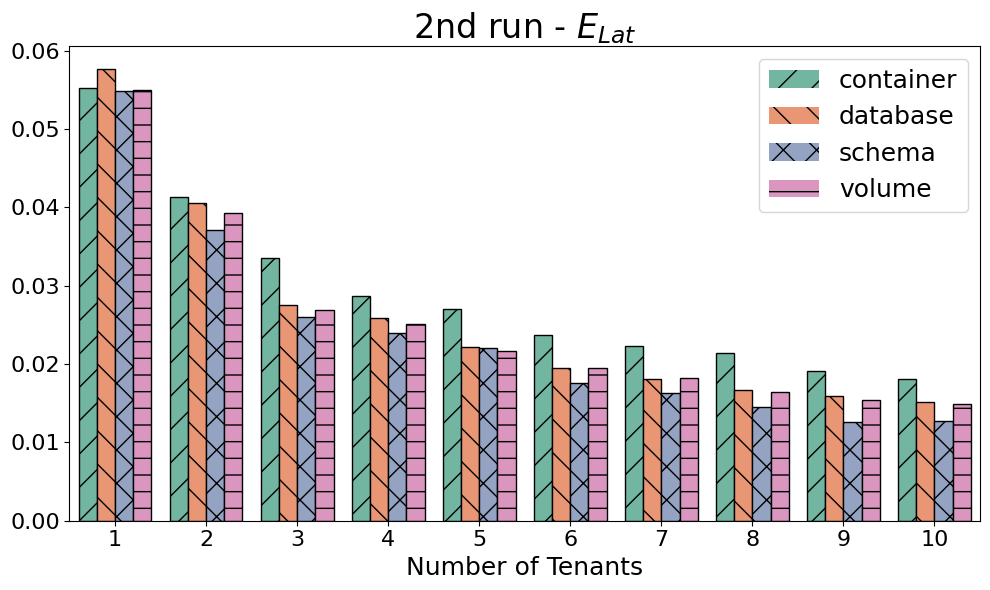

In [41]:
plot_bars(merged_df, y='E_Lat', title='2nd run - $E_{Lat}$', estimator='max')

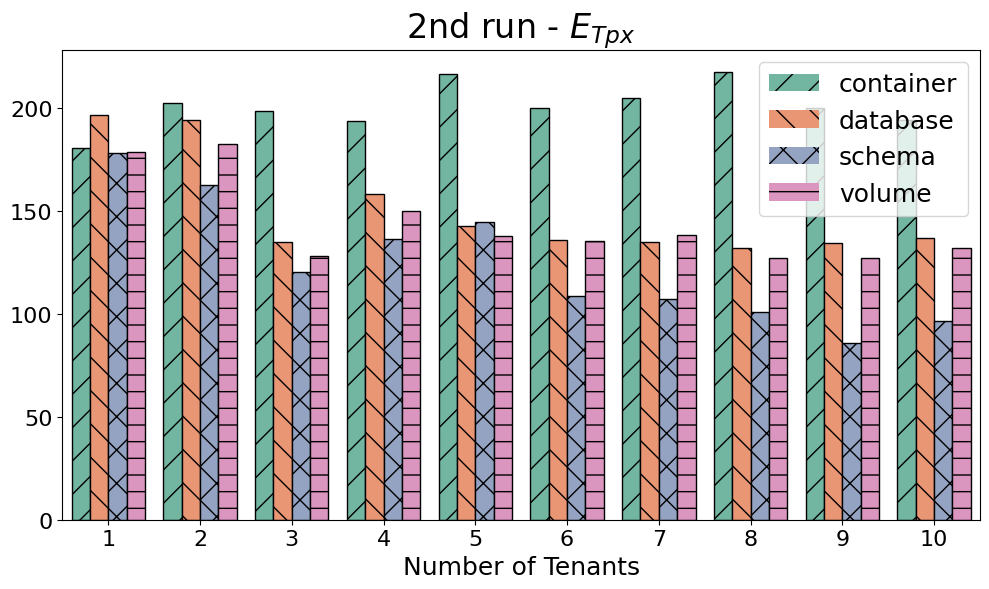

In [42]:
plot_bars(merged_df, y='E_Tpx', title='2nd run - $E_{Tpx}$', estimator='max')

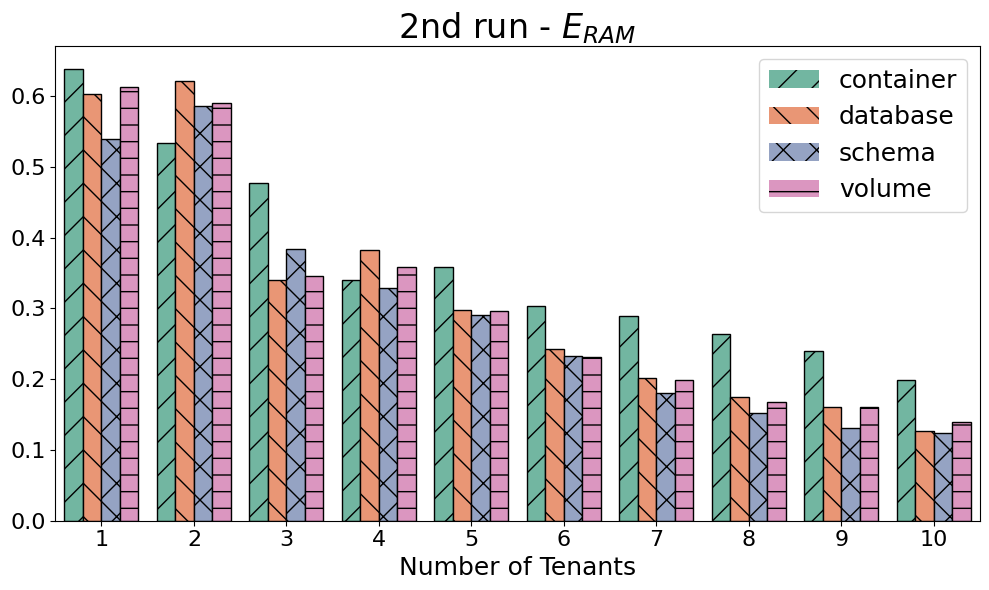

In [43]:
plot_bars(merged_df, y='E_RAM', title='2nd run - $E_{RAM}$', estimator='max')

In [44]:
import os
import zipfile

def zip_all_results():
    # Set the base directory containing the folders
    base_dir = path # "/path/to/your/folders"  # CHANGE THIS to your actual directory
    # List all folder names in the directory
    folder_names = codes
    # Create a zip for each folder
    for folder in folder_names:
        folder_path = os.path.join(base_dir, folder)
        zip_path = os.path.join(base_dir, f"{folder}.zip")
        print(f"Zipping {folder_path} to {zip_path}...")
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, _, files in os.walk(folder_path):
                for file in files:
                    abs_path = os.path.join(root, file)
                    rel_path = os.path.relpath(abs_path, folder_path)
                    zipf.write(abs_path, arcname=os.path.join(folder, rel_path))
    print("✅ Done zipping all folders.")


In [45]:
zip_all_results()

Zipping /home/perdelt/benchmarks/1765181901 to /home/perdelt/benchmarks/1765181901.zip...
Zipping /home/perdelt/benchmarks/1764926888 to /home/perdelt/benchmarks/1764926888.zip...
Zipping /home/perdelt/benchmarks/1764885402 to /home/perdelt/benchmarks/1764885402.zip...
Zipping /home/perdelt/benchmarks/1764902218 to /home/perdelt/benchmarks/1764902218.zip...
Zipping /home/perdelt/benchmarks/1765190850 to /home/perdelt/benchmarks/1765190850.zip...
Zipping /home/perdelt/benchmarks/1764904498 to /home/perdelt/benchmarks/1764904498.zip...
Zipping /home/perdelt/benchmarks/1764917698 to /home/perdelt/benchmarks/1764917698.zip...
Zipping /home/perdelt/benchmarks/1764889541 to /home/perdelt/benchmarks/1764889541.zip...
Zipping /home/perdelt/benchmarks/1764881374 to /home/perdelt/benchmarks/1764881374.zip...
Zipping /home/perdelt/benchmarks/1764869893 to /home/perdelt/benchmarks/1764869893.zip...
Zipping /home/perdelt/benchmarks/1764922484 to /home/perdelt/benchmarks/1764922484.zip...
Zipping /h